
# Seminární práce 2.
## Počítačové zpracování signálů(KI/PZS)

Autor: Rafael Gumerov (F24635)


# Klasifikace zvukových záznamů na dobré a patologické

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal
from scipy.fft import fft, ifft
import librosa

1. Nastavil jsem původní soubor.

In [3]:
base_folder = './voice-icar-federico-ii-database-1.0.0'

## 1. Iterace přes všechny záznamy 
- Funkce prochází identifikátory voice001 až voice208 a hledá příslušné soubory.
- Načtení diagnózy – z informačního souboru (-info.txt) extrahuje text diagnózy.
- Klasifikace záznamu – na základě přítomnosti slova "healthy" v diagnóze přiřazuje štítek "Healthy" nebo "Pathological".
- Získání vzorkovací frekvence – z hlavičkového souboru (.hea) načítá vzorkovací frekvenci, jinak použije výchozí hodnotu 8000 Hz.
- Načtení signálu – z textového souboru (.txt) importuje samotný hlasový signál.
- Sestavení datasetu – ukládá všechny informace (ID, signál, frekvenci, diagnózu, štítek) do DataFrame a vrací jej.

In [4]:
def load_dataset(data_dir):
    data = []
    
    for i in range(1, 209):
        file_id = f"voice{i:03d}"
        info_file = os.path.join(data_dir, f"{file_id}-info.txt")
        signal_file = os.path.join(data_dir, f"{file_id}.txt")
        header_file = os.path.join(data_dir, f"{file_id}.hea")
        
        if not os.path.exists(info_file) or not os.path.exists(signal_file):
            continue
            
        # parse Diagnosis from Info File
        diagnosis = "Unknown"
        with open(info_file, 'r') as f:
            for line in f:
                if line.strip().lower().startswith("diagnosis:"):
                    diagnosis = line.split(":", 1)[1].strip().lower()
                    break
        
        # label logic
        label = "Healthy" if "healthy" in diagnosis else "Pathological"
    
        fs = 8000 
        try:
            with open(header_file, 'r') as f:
                first_line = f.readline().split()
                if len(first_line) >= 3:
                    fs = int(first_line[2])
        except:
            pass

        # load Signal (ASCII format in .txt)
        try:
            signal = np.loadtxt(signal_file)
        except:
            continue
            
        data.append({
            'id': file_id,
            'signal': signal,
            'fs': fs,
            'diagnosis': diagnosis,
            'label': label
        })
        
    return pd.DataFrame(data)

In [5]:
df_voice = load_dataset(base_folder) 
print(f"Loaded {len(df_voice)} recordings.")
# print(df_voice["diagnosis"].value_counts())
print(df_voice['label'].value_counts())

Loaded 208 recordings.
label
Pathological    151
Healthy          57
Name: count, dtype: int64


## Vizualizace vybraných signálů

Pro lepší pochopení dat zobrazíme analýzu jednoho zdravého a jednoho patologického hlasového záznamu ve třech doménách:

1. **Časová oblast** – průběh amplitudy signálu v čase.
2. **Frekvenční spektrum (FFT)** – rozložení energie signálu v jednotlivých frekvencích.
3. **Cepstrum** – umožňuje identifikovat základní tón (F0) a hodnotit periodicitu hlasu.

Zdravý hlas vykazuje pravidelnou periodicitu a výrazné harmonické složky. Patologický hlas naopak obsahuje více šumu a slabší cepstrální vrchol.

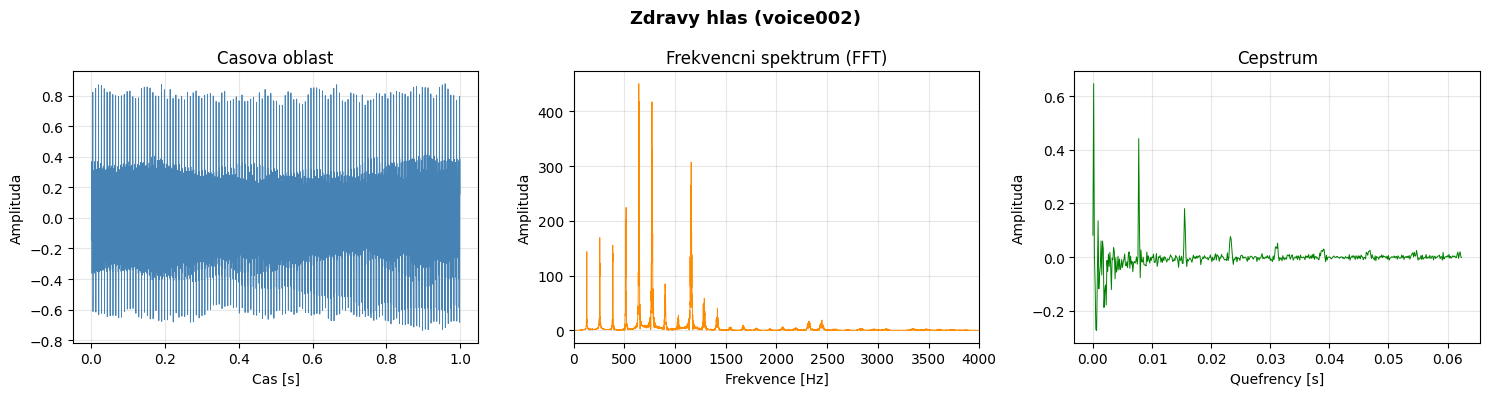

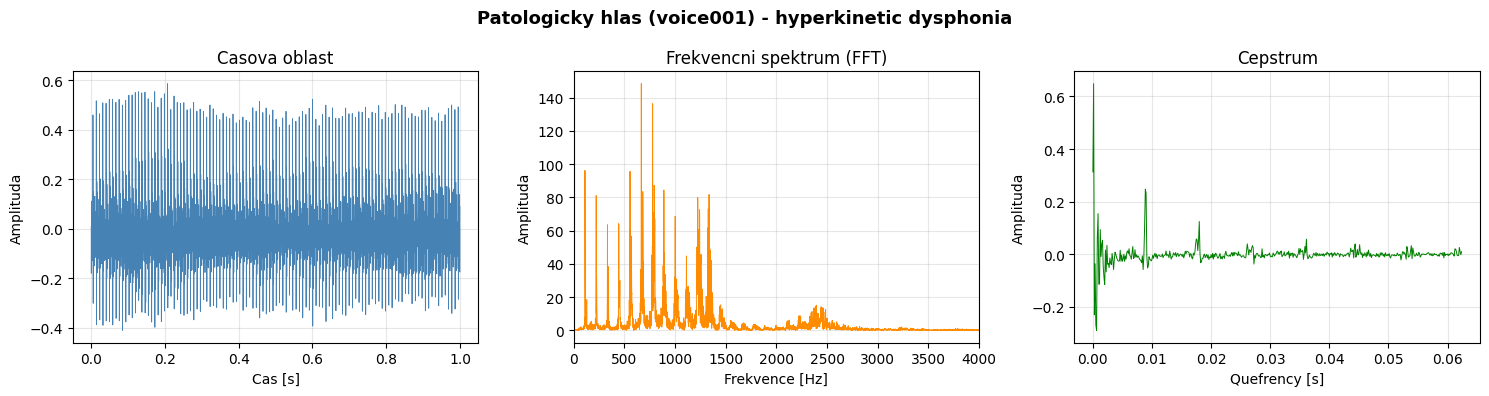

In [6]:
def plot_signal_analysis(row, title):
    signal = row['signal']
    fs = row['fs']

    center = len(signal) // 2
    win_size = min(len(signal), int(fs * 1.0))
    start = center - win_size // 2
    end = center + win_size // 2
    segment = signal[start:end]

    t = np.arange(len(segment)) / fs
    N = len(segment)
    freqs = np.fft.fftfreq(N, 1 / fs)[:N // 2]
    spectrum = np.abs(fft(segment))[:N // 2]

    eps = 1e-10
    log_spectrum = np.log(np.abs(fft(segment)) + eps)
    cepstrum = np.real(ifft(log_spectrum))
    quefrencies = np.arange(N) / fs

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    axes[0].plot(t, segment, linewidth=0.6, color='steelblue')
    axes[0].set_title('Casova oblast')
    axes[0].set_xlabel('Cas [s]')
    axes[0].set_ylabel('Amplituda')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(freqs, spectrum, linewidth=0.7, color='darkorange')
    axes[1].set_title('Frekvencni spektrum (FFT)')
    axes[1].set_xlabel('Frekvence [Hz]')
    axes[1].set_ylabel('Amplituda')
    axes[1].set_xlim(0, 4000)
    axes[1].grid(True, alpha=0.3)

    n_cep = min(500, N // 2)
    axes[2].plot(quefrencies[:n_cep], cepstrum[:n_cep], linewidth=0.7, color='green')
    axes[2].set_title('Cepstrum')
    axes[2].set_xlabel('Quefrency [s]')
    axes[2].set_ylabel('Amplituda')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


healthy_sample = df_voice[df_voice['label'] == 'Healthy'].iloc[0]
patho_sample   = df_voice[df_voice['label'] == 'Pathological'].iloc[0]

plot_signal_analysis(healthy_sample, f'Zdravy hlas ({healthy_sample["id"]})')
plot_signal_analysis(patho_sample,   f'Patologicky hlas ({patho_sample["id"]}) - {patho_sample["diagnosis"]}')

## 2. Feature Extraction

Předzpracování signálu

1. Odstranění ticha– Ořízne začátek a konec nahrávky, kde je amplituda nižší než 1 % maxima.
2. Oknování – Vybere střední úsek (maximálně 1 sekundu dlouhý) a aplikuje na něj Hammingovo okno, což je standardní postup pro spektrální analýzu, aby se zamezilo zkreslení na okrajích úseku.

Výpočet HNR (Harmonics-to-Noise Ratio)

- Počítá poměr energie harmonických složek (periodický hlas) vůči šumu.
- Využívá autokorelaci, kde hledá nejsilnější shodu signálu se sebou samým v rozsahu frekvencí lidského hlasu (60–400 Hz).
- Výsledkem je hodnota v decibelech (dB) – čím vyšší, tím je hlas "čistší" a méně chraptivý.

Výpočet CPP (Cepstral Peak Prominence)

- Provádí cepstrální analýzu (inverzní Fourierova transformace logaritmu spektra).
- Hledá tzv. cepstrální vrchol (odpovídající základní frekvenci hlasu f0) a měří, jak moc vyčnívá nad průměrnou hladinou okolí (šumem).
- Toto je robustní metoda pro hodnocení dysfonie (poruch hlasu) – vyšší hodnota znamená lepší periodicitu hlasu.

**MFCC (Mel-Frequency Cepstral Coefficients)**

Výpočet probíhá ve třech krocích:
1. Signál je rozdělen do krátkých překrývajících se rámců.
2. Pro každý rámec je vypočítáno spektrum a převedeno na mel-škálu pomocí 
   banky filtrů.
3. Aplikací diskrétní kosinové transformace (DCT) se získá 13 koeficientů 
   popisujících spektrální obal hlasu.
Jako příznak je použit **průměr každého z 13 koeficientů přes celý segment**, 


Hromadné zpracování (Smyčka)

- Kód projde každý řádek vstupní tabulky df_voice.
- Pokud je signál příliš krátký nebo nekvalitní, přiřadí náhradní hodnoty (HNR = -20, CPP = 0).
- Výsledné příznaky připojí k původním datům do nové tabulky df_final.



In [7]:
def extract_features(signal, fs):
    """
    Extracts HNR and CPP features.
    """
    # 1. Preprocessing: Silence Removal
    threshold = 0.01 * np.max(np.abs(signal))
    active_indices = np.where(np.abs(signal) > threshold)[0]
    
    if len(active_indices) < fs * 0.1:
        return None
    
    start, end = active_indices[0], active_indices[-1]
    signal_trimmed = signal[start:end]
    
    # Windowing: Center 1 second
    center_index = len(signal_trimmed) // 2
    window_size = min(len(signal_trimmed), int(fs * 1.0))
    start_win = center_index - window_size // 2
    end_win = center_index + window_size // 2
    
    segment = signal_trimmed[start_win:end_win]
    window_func = np.hamming(len(segment))
    segment_win = segment * window_func

    # 2. Fourier Analysis (Spectrum)
    N = len(segment_win)
    spectrum = np.abs(fft(segment_win))

    # 3. Cepstral Analysis (Real Cepstrum)
    eps = 1e-10
    log_spectrum = np.log(np.abs(fft(segment_win)) + eps)
    cepstrum = np.real(ifft(log_spectrum))
    
    # 4. Calculate Metrics
    
    # A. HNR via Autocorrelation
    acf = np.correlate(segment_win, segment_win, mode='full')
    acf = acf[len(acf)//2:]
    
    min_pitch, max_pitch = 60, 400
    min_lag = int(fs / max_pitch)
    max_lag = int(fs / min_pitch)
    
    hnr = -20
    if max_lag < len(acf):
        pitch_region = acf[min_lag:max_lag]
        if len(pitch_region) > 0:
            rx_t0 = np.max(pitch_region)
            rx_0 = acf[0]
            if rx_0 > rx_t0 and rx_t0 > 0.0001:
                hnr = 10 * np.log10(rx_t0 / (rx_0 - rx_t0 + eps))

    # B. CPP (Cepstral Peak Prominence)
    valid_cepstrum = cepstrum[min_lag:max_lag]
    if len(valid_cepstrum) > 0:
        cepstral_peak = np.max(valid_cepstrum)
        cpp = cepstral_peak - np.mean(cepstrum[min_lag:])
    else:
        cpp = 0
    
    # C. MFCC (13 koeficientů — průměr přes čas)
    mfcc = librosa.feature.mfcc(y=segment_win.astype(np.float32), sr=fs, n_mfcc=13)
    mfcc_means = np.mean(mfcc, axis=1)
    mfcc_feats = {f'MFCC_{i+1}': mfcc_means[i] for i in range(13)}
        
    return {'HNR': hnr, 'CPP': cpp, **mfcc_feats}

# Apply to all recordings
features_list = []
for index, row in df_voice.iterrows():
    feats = extract_features(row['signal'], row['fs'])
    if feats:
        features_list.append(feats)
    else:
        features_list.append({'HNR': -20, 'CPP': 0})

df_features = pd.DataFrame(features_list)
df_final = pd.concat([df_voice, df_features], axis=1)

print("Feature extraction complete.")

c:\Users\rafae\Desktop\ujep\malfini\HackathonHuita\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Feature extraction complete.


## Klasifikace do skupin dle diagnózy

Každá nahrávka má v informačním souboru uvedenu konkrétní diagnózu (např. *hyperkinetic dysphonia*, *laryngitis chronica* apod.).
Při pohledu na seznam diagnóz si lze všimnout, že některé třídy mají velmi málo vzorků, např. 'hypokinetic dysphonia (spasmodic dysphonia)'.
Při celkovém počtu pouze 208 nahrávek rozdělených mezi 24 diagnóz bude mít mnoho tříd jen 1–3 vzorky — to je příliš málo pro spolehlivou klasifikaci.
Tyto diagnózy seskupíme do obecnějších kategorií a zobrazíme jejich rozložení v datasetu.

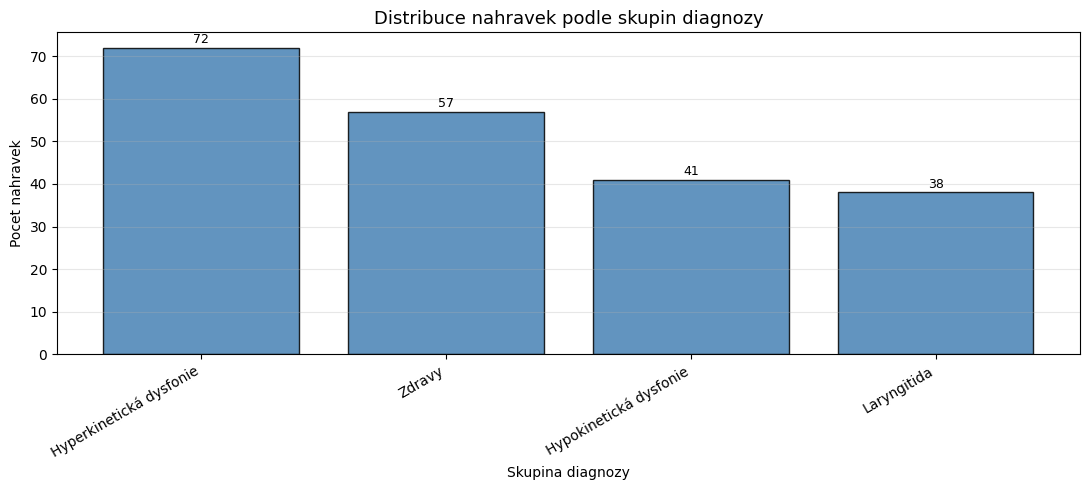


Rozlozeni napetek (Healthy / Pathological) v ramci skupin diagnozy:
diagnosis_group          label       
Hyperkinetická dysfonie  Pathological    72
Hypokinetická dysfonie   Pathological    41
Laryngitida              Pathological    38
Zdravy                   Healthy         57


In [8]:
def map_diagnosis_group(diagnosis):
    d = diagnosis.lower().strip()
    if 'healthy' in d:
        return 'Zdravy'
    elif d.startswith('hyperkinetic dysphonia'):
        return 'Hyperkinetická dysfonie'
    elif d.startswith('hypokinetic dysphonia'):
        return 'Hypokinetická dysfonie'
    elif 'laryngitis' in d:
        return 'Laryngitida'
    else:
        return 'Jine patologie'

df_final['diagnosis_group'] = df_final['diagnosis'].apply(map_diagnosis_group)

group_counts = df_final['diagnosis_group'].value_counts()

plt.figure(figsize=(11, 5))
bars = plt.bar(group_counts.index, group_counts.values, color='steelblue', edgecolor='black', alpha=0.85)
plt.title('Distribuce nahravek podle skupin diagnozy', fontsize=13)
plt.xlabel('Skupina diagnozy')
plt.ylabel('Pocet nahravek')
plt.xticks(rotation=30, ha='right')
for bar, val in zip(bars, group_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3, str(val),
             ha='center', va='bottom', fontsize=9)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\nRozlozeni napetek (Healthy / Pathological) v ramci skupin diagnozy:")
print(df_final.groupby('diagnosis_group')['label'].value_counts().to_string())

## 3. Classification Algorithm (Rule-Based)

Stanovení dynamických prahů (Trénink)

- Algoritmus se "učí" pouze ze skupiny zdravých vzorků.
- Pro oba parametry (HNR i CPP) vypočítá limitní hodnotu pomocí vzorce: $\text{Průměr} - 1 \times \text{Směrodatná odchylka}$.
- Tím se definuje spodní hranice "normality" – cokoliv, co klesne výrazně pod průměr zdravého hlasu, bude považováno za podezřelé.

Klasifikační logika (Přísné pravidlo)

- Funkce `classify_voice` hodnotí každý neznámý vzorek.
- Uplatňuje přísné kritérium pro zdraví: Aby byl hlas klasifikován jako "Healthy", musí překročit prahové hodnoty pro HNR i CPP současně (skóre 2 ze 2).
- Pokud je byť jen jeden z parametrů pod prahem (signalizuje šum nebo nepravidelnost), je vzorek okamžitě označen jako "Pathological".

Vyhodnocení modelu

- Predikce se aplikují na celý datový soubor.
- Kód porovná vypočítané štítky (`Predicted_Label`) se skutečnou diagnózou (`label`) a vypíše celkovou přesnost (accuracy) modelu v procentech.

In [9]:

healthy_data = df_final[df_final['label'] == 'Healthy']


hnr_threshold = healthy_data['HNR'].mean() - 1.0 * healthy_data['HNR'].std()
cpp_threshold = healthy_data['CPP'].mean() - 1.0 * healthy_data['CPP'].std()

print(f"Thresholds determined: HNR > {hnr_threshold:.2f}, CPP > {cpp_threshold:.2f}")

def classify_voice(row):

    score = 0
    if row['HNR'] > hnr_threshold: score += 1
    if row['CPP'] > cpp_threshold: score += 1
    
    if score == 2:
        return "Healthy"
    else:
        return "Pathological"

df_final['Predicted_Label'] = df_final.apply(classify_voice, axis=1)


correct = (df_final['label'] == df_final['Predicted_Label']).sum()
accuracy = correct / len(df_final)
print(f"Overall Accuracy: {accuracy*100:.2f}%")

Thresholds determined: HNR > 8.64, CPP > 0.24
Overall Accuracy: 54.81%


## 4. Grafické výstupy

1. Grafy signálů (čas, frekvence, cepstrum)

2. Vizualizace klasifikačního prostoru


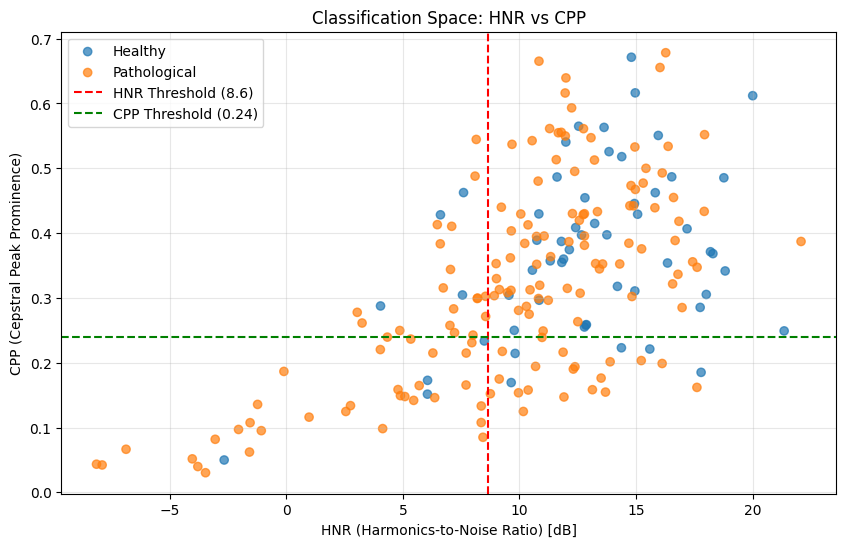

In [ ]:
plt.figure(figsize=(10, 6))

groups = df_final.groupby('label')
for name, group in groups:
    plt.scatter(group['HNR'], group['CPP'], marker='o', linestyle='', label=name, alpha=0.7)


plt.axvline(x=hnr_threshold, color='r', linestyle='--', label=f'HNR Threshold ({hnr_threshold:.1f})')
plt.axhline(y=cpp_threshold, color='g', linestyle='--', label=f'CPP Threshold ({cpp_threshold:.2f})')

plt.title("Classification Space: HNR vs CPP")
plt.xlabel("HNR (Harmonics-to-Noise Ratio) [dB]")
plt.ylabel("CPP (Cepstral Peak Prominence)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Grafické rozložení příznaků HNR a CPP potvrzuje značný překryv mezi oběma skupinami, což naznačuje, že tyto parametry samy o sobě k úplné separaci v lineárním prostoru nestačí. Výsledná přesnost modelu tak přímo odráží tuto komplexní strukturu dat, kde nelze vést jednoznačnou dělící linii bez akceptování určité míry chybovosti

## Závěr

Naměřená celková přesnost 54,81 % je z hlediska strojového učení velmi nízká. V kontextu binární klasifikace (kde náhodný tip 50/50 dává 50 %) tento výsledek naznačuje, že váš model v současné podobě téměř nefunguje.

## Random Forest klasifikátor

Příznaky HNR, CPP a MFCC jsou vstupem pro klasifikátor **Random Forest** (soubor rozhodovacích stromů).
Data jsou rozdělena na trénovací (80 %) a testovací (20 %) množinu se stratifikací dle tříd.
Model se trénuje s 200 stromy (`n_estimators=200`).

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, confusion_matrix

X = df_final[['HNR', 'CPP', 'MFCC_1', 'MFCC_2', 'MFCC_3', 'MFCC_4', 'MFCC_5', 'MFCC_6', 'MFCC_7', 'MFCC_8', 'MFCC_9', 'MFCC_10', 'MFCC_11', 'MFCC_12', 'MFCC_13']].values
y = df_final['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred)
print(f"Presnost (Accuracy) na testovaci mnozine: {accuracy_rf * 100:.2f}%")
print()
print("Klasifikacni zprava:")
print(classification_report(y_test, y_pred, target_names=['Zdravy', 'Patologicky']))

# Predikce na celem datasetu (pro sekci nize)
df_final['RF_Predicted'] = rf.predict(X)

Presnost (Accuracy) na testovaci mnozine: 71.43%

Klasifikacni zprava:
              precision    recall  f1-score   support

      Zdravy       0.50      0.08      0.14        12
 Patologicky       0.72      0.97      0.83        30

    accuracy                           0.71        42
   macro avg       0.61      0.53      0.49        42
weighted avg       0.66      0.71      0.63        42



Navržený klasifikátor na bázi Random Forest dosáhl na testovací množině celkové přesnosti 71,43 %. Model vykazuje výrazně lepší schopnost detekce patologických případů (recall 97 %, F1-skóre 0,83) než případů zdravých (recall 8 %, F1-skóre 0,14), což naznačuje silnou tendenci klasifikovat vzorky jako patologické. Tato nevyváženost výkonu je pravděpodobně způsobena nerovnoměrným zastoupením tříd v datasetu (30 patologických vs. 12 zdravých vzorků)

## Matice záměn

Matice záměn ukazuje, kolik vzorků bylo správně a nesprávně zařazeno:

- **True Positive (TP)** – správně klasifikovaný zdravý hlas.
- **True Negative (TN)** – správně klasifikovaný patologický hlas.
- **False Positive (FP)** – patologický hlas chybně označen jako zdravý.
- **False Negative (FN)** – zdravý hlas chybně označen jako patologický.

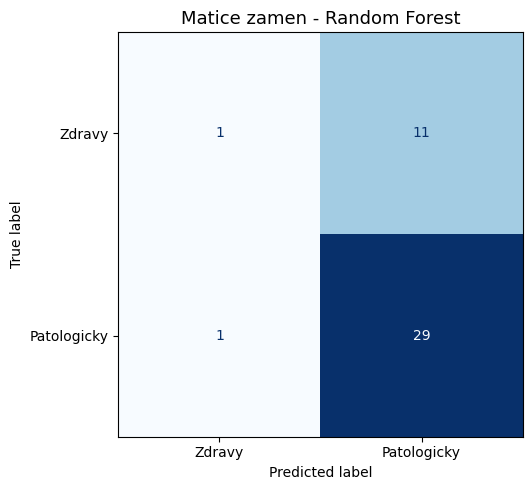

In [41]:
cm = confusion_matrix(y_test, y_pred, labels=['Healthy', 'Pathological'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Zdravy', 'Patologicky'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matice zamen - Random Forest', fontsize=13)
plt.tight_layout()
plt.show()

Z matice záměn je vidět, že model správně klasifikoval 29 z 30 patologických vzorků, avšak ze 12 zdravých vzorků správně rozpoznal pouze 1 – zbývajících 11 bylo chybně označeno jako patologické (false positives). Tento výsledek potvrzuje, že model má silnou predispozici klasifikovat vzorky jako patologické, pravděpodobně v důsledku výrazné nerovnováhy tříd v trénovacích datech.

## Příklady dobré a špatné detekce

Níže jsou zobrazeny příklady nahrávek, kde klasifikátor Random Forest uspěl (**správná detekce**),
a příklady, kde selhal (**špatná detekce**).

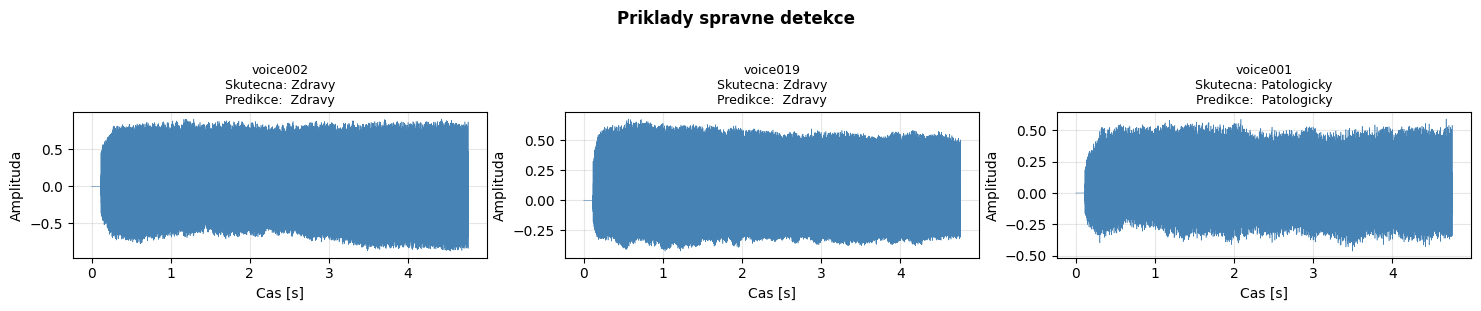

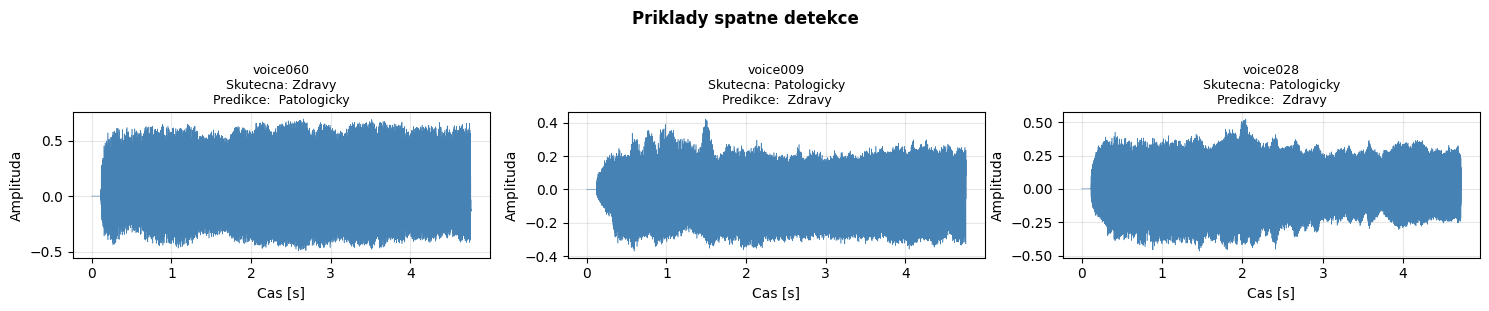

In [18]:
def plot_detection_examples(examples_df, section_title):
    n = len(examples_df)
    if n == 0:
        print(f"{section_title}: Zadne priklady nenalezeny.")
        return

    label_map = {'Healthy': 'Zdravy', 'Pathological': 'Patologicky'}
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 3))
    if n == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, examples_df.iterrows()):
        signal = row['signal']
        fs = row['fs']
        t = np.arange(len(signal)) / fs
        ax.plot(t, signal, linewidth=0.4, color='steelblue')
        true_lbl = label_map.get(row['label'], row['label'])
        pred_lbl = label_map.get(row['RF_Predicted'], row['RF_Predicted'])
        ax.set_title(f"{row['id']}\nSkutecna: {true_lbl}\nPredikce:  {pred_lbl}", fontsize=9)
        ax.set_xlabel('Cas [s]')
        ax.set_ylabel('Amplituda')
        ax.grid(True, alpha=0.3)

    fig.suptitle(section_title, fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


# Spravna detekce: 2 zdrave + 1 patologicka
tp_healthy = df_final[
    (df_final['label'] == 'Healthy') & (df_final['RF_Predicted'] == 'Healthy')
].head(2)
tp_patho = df_final[
    (df_final['label'] == 'Pathological') & (df_final['RF_Predicted'] == 'Pathological')
].head(1)
good_examples = pd.concat([tp_healthy, tp_patho])

# Spatna detekce: FN + FP
fn = df_final[
    (df_final['label'] == 'Healthy') & (df_final['RF_Predicted'] == 'Pathological')
].head(1)
fp = df_final[
    (df_final['label'] == 'Pathological') & (df_final['RF_Predicted'] == 'Healthy')
].head(2)
bad_examples = pd.concat([fn, fp])

plot_detection_examples(good_examples, 'Priklady spravne detekce')
plot_detection_examples(bad_examples,  'Priklady spatne detekce')

## Závěr:

Špatná detekce je způsobena hlavně tím, že dataset není vyvážený – v celém datasetu je 151 patologických nahrávek oproti 57 zdravým, takže model se jednoduše více přiklonil k patologické třídě. I přes použití HNR, CPP a MFCC koeficientů zůstávají některé nahrávky těžko rozlišitelné, protože hlasové patologie se mohou projevovat velmi subtilně. Pro zlepšení výsledků by pomohlo vyrovnat počty tříd v trénovacích datech – například pomocí techniky SMOTE nebo nastavením vah tříd – a případně rozšířit dataset o více nahrávek zdravých mluvčích.